# Coding Project 1: Linear Regression and Regularization

**Please write the names of all group members here:**

Giacomo Maggiore

Ugo Buzzacchino

Konstantin Krstevski

Kostas Zisis


---

*Note:* The provided structure for the code below is only suggestive. You may structure your program differently, provided that your notebook is readable, reproducible, and answers all questions clearly.

A minimal `sklearn` workflow example is included before Question 3. It is intended to illustrate the use of `ColumnTransformer`, `Pipeline`, and `GridSearchCV`; it does **not** solve the project questions for you.

### Question 1 - Importing and Preparing the Data


Task 1.a ----------------------------------------------------

X: (1460, 79), y: (1460,) | numerical: 35, categorical: 44

Task 1.b ----------------------------------------------------



/var/folders/9_/51m0drvn29bc0q_f8x0y62jw0000gn/T/ipykernel_11774/2865817848.py:74: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[2].boxplot(sale_price, vert=False)


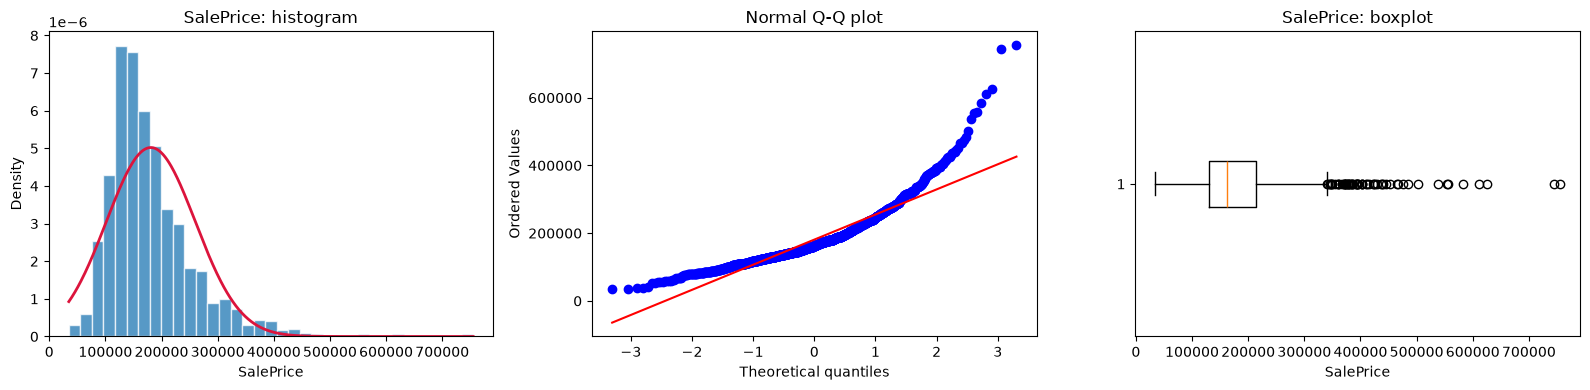

Skewness: 1.883
Excess kurtosis: 6.536
Mean: $180,921
Median: $163,000

- Skewness > 0 and mean > median: the distribution has a long tail to the right (right-skewed).
- Excess kurtosis > 0: there are more extreme values than in a normal distribution.
- Histogram: the long right tail does not follow the red normal curve.
- Q-Q plot: the points form a curve, not a straight line. In both tails they are above the red line:
  the cheapest houses are more expensive, and the most expensive houses are much more expensive,
  than a normal distribution would predict.
- Boxplot: there are many very expensive outliers on the right, and none on the left.
=> SalePrice is not approximately Gaussian.



,skewness,excess kurtosis
none,1.883,6.536
sqrt,0.943,1.958
log1p,0.121,0.810
1/y,2.142,10.889
Box-Cox,-0.009,0.878


Box-Cox finds lambda = -0.077. This is close to 0, so the best power transformation is almost the log.
log1p gives almost the same skewness, its coefficients are easy to read as percentages, and it is easy
to invert with expm1. So we use log1p.

Transformation: log1p(SalePrice) to reduce skewness and heavy tails.


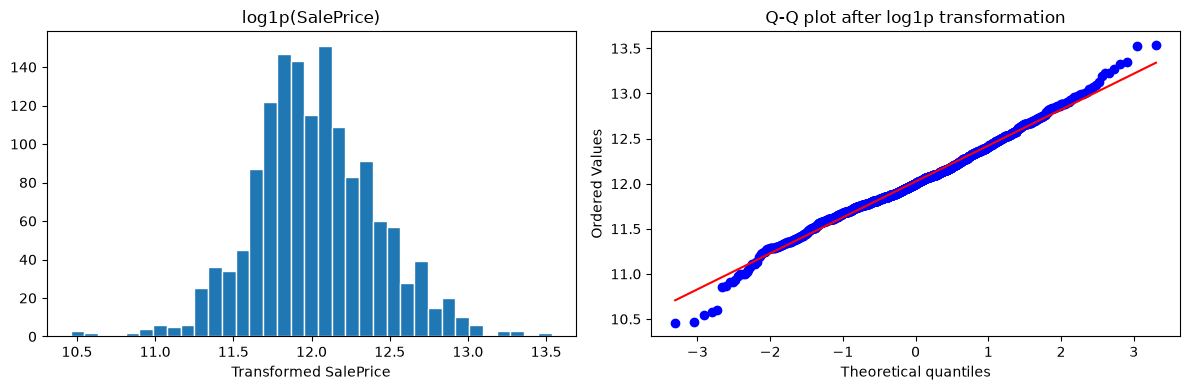

Why do we transform SalePrice?
- The t-tests and confidence intervals of OLS (Question 2.b) assume that the errors are normal and have
  constant variance. With a right-skewed target, the errors are also skewed, and they are usually larger
  for expensive houses.
- On the log scale, the effects of the features are in percent: a coefficient beta means that the price
  changes by about 100*beta percent when the feature increases by one standard deviation. For prices this
  is more realistic than a fixed change in dollars.
- Without the transformation, the few very expensive houses would have too much weight in the squared errors.
- After log1p, the skewness falls from 1.883 to 0.121, and the Q-Q plot is close to the
  red line, except for a few cheap houses in the lower tail.

Task 1.c ----------------------------------------------------

Test size: 30% of the data
X_train_raw: (1022, 79), X_test_raw: (438, 79), y_train: (1022,), y_test: (438,)

Task 1.d ---------------------------------

,train,test,filled with
LotFrontage,190,69,mean
MasVnrType,3,5,mode
MasVnrArea,3,5,mean
Electrical,1,0,mode
GarageYrBlt,54,27,mean


Prepared X_train: (1022, 311), X_test: (438, 311); same columns in the same order.


In [1]:
# For Question 1, you may find the following packages useful:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
import re
from sklearn.model_selection import train_test_split
from pathlib import Path

output_dir = Path("output")  # figures and tables are saved here
output_dir.mkdir(exist_ok=True)

# 1.a) Import Housing.csv as a pandas DataFrame.
# Separate the explanatory features X from the target y = SalePrice.
#
# Guidance:
# - Refer to data_description.txt to determine how variables should be interpreted.
# - The first column of the csv file is an index and should not be used as an explanatory variable.
# - Keep the original variable names so that later coefficient tables are easy to interpret.

# Variable types come from data_description.txt, not from the dtypes:
# MSSubClass is stored as integers but is categorical.

print("\nTask 1.a ----------------------------------------------------\n")


types = pd.Series(dict(re.findall(r"^(\w+) \((numerical|categorical)\):",
                                  Path("data/data_description.txt").read_text(), flags=re.M)))
NUMERICAL = types.index[types == "numerical"].tolist()
CATEGORICAL = types.index[types == "categorical"].tolist()

# By default, pandas reads 'NA' and 'None' as missing values (NaN). But for many categorical
# variables they are real levels (for example 'NA' = "no garage"). So we read 'NA' as missing
# only in the numerical columns and in MasVnrType and Electrical, where 'NA' is not a level
# in data_description.txt. These missing values are filled in 1.d).
data = pd.read_csv("data/Housing.csv", index_col=0, keep_default_na=False,
                   na_values={col: ["NA"] for col in NUMERICAL + ["MasVnrType", "Electrical"]},
                   dtype={col: str for col in CATEGORICAL})
X = data.drop(columns="SalePrice")
y = data["SalePrice"]

assert sorted(X.columns) == sorted(types.index)
print(f"X: {X.shape}, y: {y.shape} | numerical: {len(NUMERICAL)}, categorical: {len(CATEGORICAL)}")

print("\nTask 1.b ----------------------------------------------------\n")


# 1.b) Graphically determine whether SalePrice is approximately Gaussian.
# If it is not, suggest and apply a suitable transformation.
# Explain why considering such a transformation can be important.
#
# Guidance:
# - Use suitable graphical diagnostics (for example, a histogram and/or Q-Q plot).
# - Keep track of the transformation you choose because later questions require metrics
#   both on the transformed scale and, after inverse transformation, on the original
#   SalePrice scale.

sale_price = pd.to_numeric(y).dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram with fitted Gaussian reference curve
axes[0].hist(sale_price, bins=35, density=True, alpha=0.75, edgecolor="white")
mu, sigma = sale_price.mean(), sale_price.std()
x = np.linspace(sale_price.min(), sale_price.max(), 400)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), color="crimson", lw=2)
axes[0].set(title="SalePrice: histogram", xlabel="SalePrice", ylabel="Density")

# Normal Q-Q plot
stats.probplot(sale_price, dist="norm", plot=axes[1])
axes[1].set_title("Normal Q-Q plot")

# Boxplot
axes[2].boxplot(sale_price, vert=False)
axes[2].set(title="SalePrice: boxplot", xlabel="SalePrice")

plt.tight_layout()
fig.savefig(output_dir / "q1b_saleprice_before_transformation.png", dpi=150)
plt.show()

print(f"Skewness: {sale_price.skew():.3f}")
print(f"Excess kurtosis: {sale_price.kurt():.3f}")
print(f"Mean: ${sale_price.mean():,.0f}")
print(f"Median: ${sale_price.median():,.0f}")
print("""
- Skewness > 0 and mean > median: the distribution has a long tail to the right (right-skewed).
- Excess kurtosis > 0: there are more extreme values than in a normal distribution.
- Histogram: the long right tail does not follow the red normal curve.
- Q-Q plot: the points form a curve, not a straight line. In both tails they are above the red line:
  the cheapest houses are more expensive, and the most expensive houses are much more expensive,
  than a normal distribution would predict.
- Boxplot: there are many very expensive outliers on the right, and none on the left.
=> SalePrice is not approximately Gaussian.
""")

# Compare possible transformations. Box-Cox finds the best power transformation from the data
# (lambda = 0 means the log).
_, boxcox_lambda = stats.boxcox(sale_price)
transformed = pd.DataFrame({"none": sale_price, "sqrt": np.sqrt(sale_price), "log1p": np.log1p(sale_price),
                            "1/y": 1 / sale_price, "Box-Cox": stats.boxcox(sale_price, boxcox_lambda)})
display(pd.DataFrame({"skewness": transformed.skew(), "excess kurtosis": transformed.kurt()}).round(3))
print(f"Box-Cox finds lambda = {boxcox_lambda:.3f}. This is close to 0, so the best power transformation is almost the log.\n"
      "log1p gives almost the same skewness, its coefficients are easy to read as percentages, and it is easy\n"
      "to invert with expm1. So we use log1p.\n")

print("Transformation: log1p(SalePrice) to reduce skewness and heavy tails.")
# Preserve the original scale for later evaluation
y_original = y.copy()

# Transform the regression target. log1p has no fitted parameter, so transforming y before the split causes
# no leakage. The Box-Cox lambda above (fitted on all houses) is only used to compare transformations.
y = np.log1p(y_original)

# Confirm that inverse transformation recovers SalePrice
assert np.allclose(np.expm1(y), y_original)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=35, edgecolor="white")
axes[0].set(title="log1p(SalePrice)", xlabel="Transformed SalePrice")

stats.probplot(y, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot after log1p transformation")

plt.tight_layout()
fig.savefig(output_dir / "q1b_saleprice_after_transformation.png", dpi=150)
plt.show()

print(f"""Why do we transform SalePrice?
- The t-tests and confidence intervals of OLS (Question 2.b) assume that the errors are normal and have
  constant variance. With a right-skewed target, the errors are also skewed, and they are usually larger
  for expensive houses.
- On the log scale, the effects of the features are in percent: a coefficient beta means that the price
  changes by about 100*beta percent when the feature increases by one standard deviation. For prices this
  is more realistic than a fixed change in dollars.
- Without the transformation, the few very expensive houses would have too much weight in the squared errors.
- After log1p, the skewness falls from {y_original.skew():.3f} to {y.skew():.3f}, and the Q-Q plot is close to the
  red line, except for a few cheap houses in the lower tail.""")

print("\nTask 1.c ----------------------------------------------------\n")


# 1.c) Split the data into training and test sets.
# Randomly assign 70% of the observations to the training set and 30% to the test set.
#
# IMPORTANT:
# - Save an UNPROCESSED copy of X_train and X_test before doing any imputation,
#   standardization, or one-hot encoding.
# - You will return to these raw splits in Question 3.b) to build a leakage-safe
#   cross-validation pipeline.
#
# Suggested naming:
# X_train_raw, X_test_raw, y_train, y_test

# Train-test split (the test share is set by TEST_SIZE)
TEST_SIZE = 0.3

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42)

print(f"Test size: {TEST_SIZE:.0%} of the data")
print(f"X_train_raw: {X_train_raw.shape}, X_test_raw: {X_test_raw.shape}, y_train: {y_train.shape}, y_test: {y_test.shape}")

print("\nTask 1.d ----------------------------------------------------\n")


# 1.d) Prepare X_train and X_test using TRAINING-SET information only.
#
# Required steps:
# (i)   Numerical missing values: impute with the corresponding training-set mean.
# (ii)  Categorical missing values: impute with the most frequent category in the
#       corresponding training column.
# (iii) Treat 'NA' / 'None' as actual categorical levels where the data description
#       specifies that they are valid categories, rather than automatically treating
#       them as missing.
# (iv)  Standardize numerical features using training-set means and standard deviations,
#       and apply the same transformation, using these training-set statistics, to
#       the test set.
# (v)   One-hot encode the categorical variables.
# (vi)  Ensure that the test set contains the same encoded feature columns, in the
#       same order, as the training set.
#
# Hint:
# If pd.get_dummies is applied separately to the training and test sets, they may
# produce different dummy-variable columns because some categorical levels occur
# in only one of the two sets. The regression model must receive the same feature
# columns at training and prediction time. One possible way to align the encoded
# test columns to the training columns is:
#
# X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
#
# This creates any training dummy column missing from the test set and fills it
# with zero, while also matching the training-column order.
#
# Expected output / checks:
# - Report the final shapes of the prepared training and test feature matrices.
# - Verify that the encoded feature columns and their order are identical.
# - Do not use any test-set statistic to fit the preprocessing.

# 1.d) Training-only preprocessing

# Work from the raw splits
X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

# Truly missing values (NaN). Documented 'NA'/'None' levels are categories (see 1.a), so they are not counted here.
missing = pd.DataFrame({"train": X_train_raw.isna().sum(), "test": X_test_raw.isna().sum()})
missing = missing[missing.sum(axis=1) > 0]
missing["filled with"] = np.where(missing.index.isin(NUMERICAL), "mean", "mode")
print("Missing values and how they are filled:")
display(missing)

# Numerical features
X_train_num = X_train[NUMERICAL].apply(pd.to_numeric, errors="coerce")
X_test_num = X_test[NUMERICAL].apply(pd.to_numeric, errors="coerce")

# First fill missing values with the training mean, then standardize with the training mean and
# standard deviation. The standard deviation is computed after filling, with ddof=0, like StandardScaler in Question 3.
train_means = X_train_num.mean()
X_train_num = X_train_num.fillna(train_means)
X_test_num = X_test_num.fillna(train_means)

train_stds = X_train_num.std(ddof=0).replace(0, 1)
X_train_num = (X_train_num - train_means) / train_stds
X_test_num = (X_test_num - train_means) / train_stds

# Categorical features
X_train_cat = X_train[CATEGORICAL].copy()
X_test_cat = X_test[CATEGORICAL].copy()

train_modes = X_train_cat.mode().iloc[0]

X_train_cat = X_train_cat.fillna(train_modes)
X_test_cat = X_test_cat.fillna(train_modes)

# One-hot encode: pd.get_dummies keeps one column for each of the k levels
X_train_cat = pd.get_dummies(X_train_cat, dtype=int)
X_test_cat = pd.get_dummies(X_test_cat, dtype=int)

# Match test columns to training columns
X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)

# Combine numerical and categorical features
X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_test = pd.concat([X_test_num, X_test_cat], axis=1)


# assert checks that a condition is true.
assert X_train.columns.equals(X_test.columns)
print(f"Prepared X_train: {X_train.shape}, X_test: {X_test.shape}; same columns in the same order.")

### Question 2 - Linear Regression on Numerical Features


Task 2.a ----------------------------------------------------



,feature,coefficient
0,Intercept,12.02890
1,LotFrontage,-0.00118
2,LotArea,0.02145
3,OverallQual,0.11428
4,OverallCond,0.04793
5,YearBuilt,0.09138
6,YearRemodAdd,0.02755
7,MasVnrArea,-0.00648
8,BsmtFinSF1,0.00972
9,BsmtFinSF2,0.00154


Units: the target is log1p(SalePrice) and the features are standardized. So a coefficient b means that the price
is about 100*b % higher when the feature is one standard deviation higher and the other features stay the same.
The 8 basement and living-area coefficients are not unique, because these columns have exact linear relations
(see 2.b). sklearn reports the solution with the smallest norm, so these 8 values should not be read one by one.



,sample,target_scale,MSE,R2
0,In-sample,log1p(SalePrice),0.02200,0.85810
1,Out-of-sample,log1p(SalePrice),0.02187,0.87109
2,In-sample,SalePrice (USD),"1,433,790,871",0.76177
3,Out-of-sample,SalePrice (USD),"829,116,180",0.88118



Comparison of the two scales:

- Log scale: the model is fitted on this scale. 
  MSE and R2 measure relative (percentage) errors.
  Train and test are almost equal (R2 0.858 vs 0.871), so the numerical model does not overfit.

- Dollar scale: MSE is in USD^2 and shows how large the price errors are in practice. Because the errors are
  squared, expensive houses and large errors count much more. Here the in-sample R2 (0.762) is even
  lower than the out-of-sample R2 (0.881).

- The reason is two training houses: Id 1299 (5,642 sq ft, sold for $160,000, predicted $854,432) and
  Id 524 (4,676 sq ft, sold for $184,750, predicted $668,492).
  Together they cause about 49% of the in-sample squared error in dollars. Both are very large houses
  that were sold cheaply ('Partial' sales). Without them, the in-sample R2 is 0.88, close to the test value.

- Generally speaking, the log metrics show the typical relative accuracy. The dollar metrics depend strongly on a few
  large errors and on w

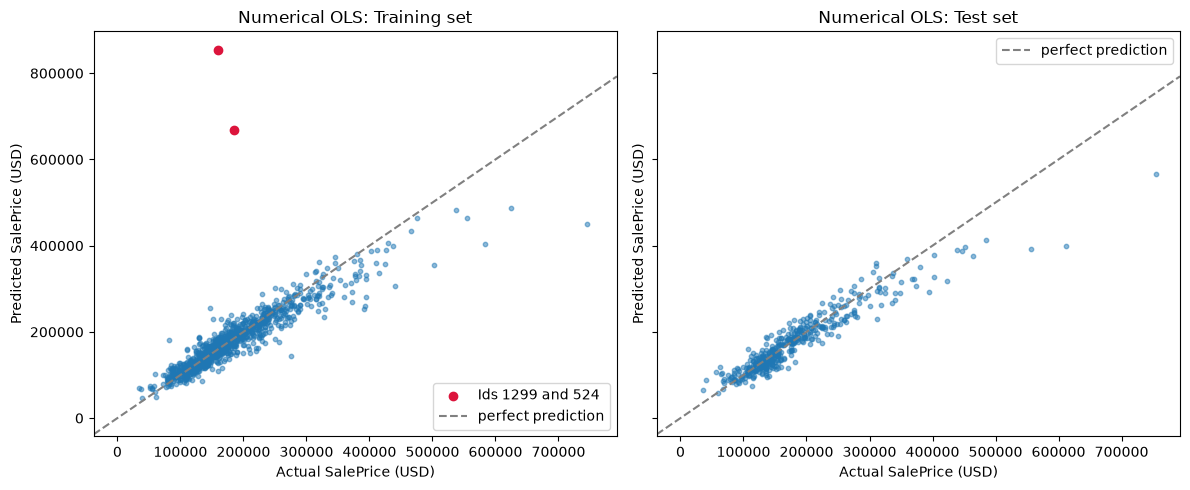


Task 2.b ----------------------------------------------------

2.b(i) Coefficients: np.linalg.solve vs sklearn


,feature,beta_numpy_solve,beta_sklearn,abs_difference
0,Intercept,12.02890,12.02890,0.00000
1,LotFrontage,-0.00118,-0.00118,0.00000
2,LotArea,0.02145,0.02145,0.00000
3,OverallQual,0.11428,0.11428,0.00000
4,OverallCond,0.04793,0.04793,0.00000
5,YearBuilt,0.09138,0.09138,0.00000
6,YearRemodAdd,0.02755,0.02755,0.00000
7,MasVnrArea,-0.00648,-0.00648,0.00000
8,BsmtFinSF1,0.19623,0.00972,0.18651
9,BsmtFinSF2,0.06286,0.00154,0.06131


 
Intercept (row 0, beta_0): numpy 12.02890 | sklearn 12.02890
 
Coefficients differing from sklearn by more than 1e-8: ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea']
 
Max abs difference between numpy and sklearn fitted values: 5.9e-14

- The intercept and 27 of the 35 slopes are the same as in sklearn (except for rounding errors).

- The 8 area features are very different, but both models give the same fitted values.

- Reason (shown in (iv)): these columns are linearly dependent. So A^T A is singular, and the normal equations
  have infinitely many solutions. np.linalg.solve gives no error only because rounding errors make A^T A look
  invertible. It returns an arbitrary solution that depends only on rounding errors. sklearn instead uses a
  least-squares solver that returns the unique solution with the smallest norm.

- So here the system is NOT numerically well behaved: we must not interpret the solve coefficients of t

,feature,coefficient,standard_error
0,Intercept,12.02890,0.00472
1,LotFrontage,-0.00118,0.00566
2,LotArea,0.02145,0.00532
3,OverallQual,0.11428,0.00846
4,OverallCond,0.04793,0.00595
5,YearBuilt,0.09138,0.01084
6,YearRemodAdd,0.02755,0.00746
7,MasVnrArea,-0.00648,0.00563
8,BsmtFinSF1,0.19623,"88,176"
9,BsmtFinSF2,0.06286,"28,987"



Standard-error summary
Residual variance: sigma^2 = RSS / (m - p) = 22.47924 / 986 = 0.02280
Intercept: beta_0 = 12.02890, SE = 0.00472

The intercept is the predicted log sale price when every standardized feature is at its training
average (zero). This is why beta_0 equals mean(y_train) = 12.02890.
Its SE is sigma / sqrt(m) = 0.00472.


2.b(iii) In-sample MSE and R^2: matrix algebra vs sklearn (2.a)


,target_scale,MSE_matrix_algebra,MSE_sklearn_2a,R2_matrix_algebra,R2_sklearn_2a
0,log1p(SalePrice),0.02200,0.02200,0.85810,0.85810
1,SalePrice (USD),"1,433,790,871","1,433,790,871",0.76177,0.76177


In-sample MSE and R^2 agree with 2.a up to rounding: True

- They agree on both scales, even though some coefficients are different from sklearn (see (i)).

2.b(iv) Rank and singular values of A
 
A: 1022 x 36 | rank(A) = 34 | full column rank: False
 
Largest singular value:   84.90397
 
Smallest singular values: [1.183e+01 1.096e+01 9.923e+00 8.089e-15 7.006e-15]
 
condition number: cond(A) = s_max / s_min = 1.2e+16 (1 / machine epsilon = 4.5e+15)
 
cond(A) without the two near-zero directions = s_max / s_34 = 8.6
 
Features in the null space of A: ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea']
 


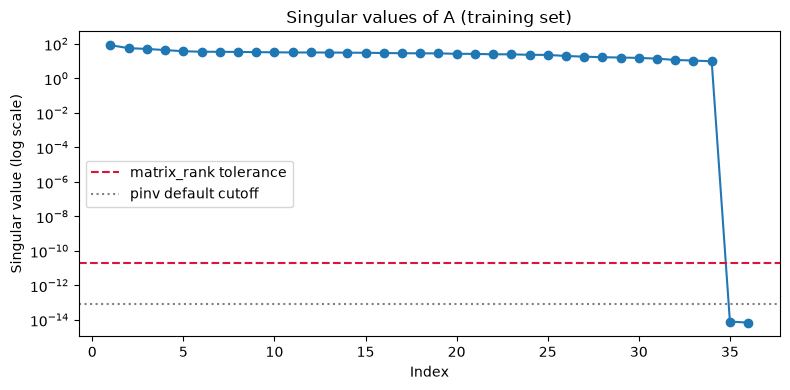


- A does NOT have full column rank: rank 34 < 36 columns, so there are 2 exact linear dependencies.

- They come from two accounting identities that hold in every training row (checked above):
  TotalBsmtSF = BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF and GrLivArea = 1stFlrSF + 2ndFlrSF + LowQualFinSF.
  These columns have no missing values, so mean imputation changes nothing. Standardization is a linear
  (affine) change, so the identities stay exact linear relations between the columns of A.
  The null space contains exactly these 8 features.

- The two smallest singular values (~1e-14) are zero except for rounding errors. They are about 15 orders of
  magnitude smaller than the next one (9.92). Without these two directions, A is well
  conditioned (ratio ~9). So the problem is exact collinearity, not just strong correlation.

- Link to (i)-(iii): cond(A) is about 1 / machine epsilon, and the normal equations square it
  (cond(A^T A) = cond(A)^2). So A^T A is numerically singular. This exp

,feature,beta_solve,beta_pinv,se_solve,se_pinv
0,Intercept,12.02890,12.02890,0.00472,0.00472
1,LotFrontage,-0.00118,-0.00118,0.00566,0.00566
2,LotArea,0.02145,0.02145,0.00532,0.00532
3,OverallQual,0.11428,0.11428,0.00846,0.00846
4,OverallCond,0.04793,0.04793,0.00595,0.00595
5,YearBuilt,0.09138,0.09138,0.01084,0.01084
6,YearRemodAdd,0.02755,0.02755,0.00746,0.00746
7,MasVnrArea,-0.00648,-0.00648,0.00563,0.00563
8,BsmtFinSF1,0.19623,0.00972,"88,176",0.00530
9,BsmtFinSF2,0.06286,0.00154,"28,987",0.00489


Singular values discarded by pinv (below 8.5e-14): 2

Coefficients that change: ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea']

Standard errors that change: ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea']

sigma^2: solve 0.02279841 | pinv 0.02279841 | |difference| 2.1e-17

Max |beta_pinv - beta_sklearn|: 1.1e-14


- beta: the intercept and the other (non-area) slopes do not change. The 8 area features change:
  pinv sets 1/s to zero for the two singular values below the cutoff and returns the unique solution with the
  smallest norm. This is exactly the sklearn solution from 2.a.

- sigma^2: no change, so the same residuals and RSS.

- SEs: no change for the other coefficients. For the 8 area features, they go from huge or NaN
  values to 0.00471-0.00782, because the exploding 1/s^2 terms of the null directions are removed.

- The results can be identical when A 

/var/folders/9_/51m0drvn29bc0q_f8x0y62jw0000gn/T/ipykernel_11774/3151485657.py:402: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols_statsmodels = sm.OLS(y_vec, A).fit()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       log1p(SalePrice)   R-squared:                       0.858
Model:                            OLS   Adj. R-squared:                  0.853
Method:                 Least Squares   F-statistic:                     181.0
Date:                Tue, 06 Oct 2026   Prob (F-statistic):               0.00
Time:                        21:37:57   Log-Likelihood:                 500.29
No. Observations:                1022   AIC:                            -932.6
Df Residuals:                     988   BIC:                            -765.0
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        12.0289      0.005   2549.406      0.000      12.020      12.038
LotFrontage      -0.0012      0.006     -0.209      0.834      -0.012       0.010
LotArea           0.0214      0.005      4.040      0.000       0.011       0.032
OverallQual       0.1143      0.008     13.525      0.000       0.098       0.131
OverallCond       0.0479      0.006      8.057      0.000       0.036       0.060
YearBuilt         0.0914      0.011      8.440      0.000       0.070       0.113
YearRemodAdd      0.0276      0.007      3.695      0.000       0.013       0.042
MasVnrArea       -0.0065      0.006     -1.152      0.250      -0.018       0.005
BsmtFinSF1        0.0097      0.005      1.836      0.067      -0.001       0.020
BsmtFinSF2        0.0015      0.005      0.316      0.752      -0.008       0.011
BsmtUnfSF         0.0022      0.005      0.470      0.638      -0.007       0.011
TotalBsmtSF       0.0127      0.007      1.935      0.053      -0.000       0.026
1stFlrSF          0.0391      0.008      5.005      0.000       0.024       0.054
2ndFlrSF          0.0197      0.007      3.000      0.003       0.007       0.033
LowQualFinSF      0.0054      0.005      1.076      0.282      -0.004       0.015
GrLivArea         0.0455      0.007      6.403      0.000       0.032       0.059
BsmtFullBath      0.0342      0.007      4.872      0.000       0.020       0.048
BsmtHalfBath      0.0030      0.005      0.584      0.559      -0.007       0.013
FullBath          0.0163      0.008      2.034      0.042       0.001       0.032
HalfBath          0.0117      0.007      1.703      0.089      -0.002       0.025
BedroomAbvGr      0.0067      0.007      0.911      0.363      -0.008       0.021
KitchenAbvGr     -0.0243      0.006     -4.316      0.000      -0.035      -0.013
TotRmsAbvGrd      0.0302      0.011      2.839      0.005       0.009       0.051
Fireplaces        0.0336      0.006      5.640      0.000       0.022       0.045
GarageYrBlt      -0.0119      0.009     -1.384      0.167      -0.029       0.005
GarageCars        0.0599      0.011      5.460      0.000       0.038       0.081
GarageArea        0.0117      0.011      1.065      0.287      -0.010       0.033
WoodDeckSF        0.0158      0.005      3.015      0.003       0.006       0.026
OpenPorchSF      -0.0048      0.005     -0.919      0.358      -0.015       0.005
EnclosedPorch     0.0122      0.005      2.252      0.025       0.002       0.023
3SsnPorch         0.0106      0.005      2.224      0.026       0.001       0.020
ScreenPorch       0.0212      0.005      4.203      0.000       0.011       0.031
PoolArea         -0.0207      0.005     -3.976      0.000      -0.031      -0.010
MiscVal          -0.0040      0.005     -0.827      0.409      -0.014       0.006
MoSold            0.0056      0.005      1.159   

,feature,beta_statsmodels,se_statsmodels,beta_pinv,se_pinv,se_ratio_statsmodels_to_pinv
0,Intercept,12.02890,0.00472,12.02890,0.00472,0.99899
1,LotFrontage,-0.00118,0.00566,-0.00118,0.00566,0.99899
2,LotArea,0.02145,0.00531,0.02145,0.00532,0.99899
3,OverallQual,0.11428,0.00845,0.11428,0.00846,0.99899
4,OverallCond,0.04793,0.00595,0.04793,0.00595,0.99899
5,YearBuilt,0.09138,0.01083,0.09138,0.01084,0.99899
6,YearRemodAdd,0.02755,0.00746,0.02755,0.00746,0.99899
7,MasVnrArea,-0.00648,0.00562,-0.00648,0.00563,0.99899
8,BsmtFinSF1,0.00972,0.00530,0.00972,0.00530,0.99899
9,BsmtFinSF2,0.00154,0.00489,0.00154,0.00489,0.99899


Max |beta_statsmodels - beta_pinv|: 0.0e+00

Max |beta_statsmodels - beta_solve| (area features): 1.9e-01

statsmodels residual df = m - rank(A) = 1022 - 34 = 988
| formula above: m - (d + 1) = 986

sigma^2: statsmodels 0.02275226 | matrix algebra 0.02279841

SE ratio statsmodels / pinv: 0.998987 to 0.998987
 | sqrt(986 / 988) = 0.998987

Max |SE difference| after using the same df: 3.5e-18

Smallest eigenvalue of A^T A reported by statsmodels: 4.9e-29


- Coefficients: statsmodels gives the same estimates as pinv (and sklearn), except for rounding errors, also for
  the 8 area features. It does not match the solve values for these features (see (i)).

- Standard errors: all are smaller by the same factor 0.99899. The only reason is the degrees of freedom.
  statsmodels uses the numerical rank: df_resid = m - rank(A) = 988. Our formula uses m - (d + 1) = 986.
  With the same df, the SEs are equal except for rounding errors.

- This difference comes directly from the rank deficiency fou

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

def show_and_save(table, file_name):
    """Display a table (5 decimals, large values with thousands separators) and save it to output/."""
    with pd.option_context("display.float_format", lambda v: f"{v:,.0f}" if abs(v) >= 1e3 else f"{v:.5f}"):
        display(table)
    table.to_csv(output_dir / file_name, index=False, float_format="%.5f")

#=============================================================================================

# 2.a) Fit an OLS regression using ONLY the numerical predictors and sklearn.
# Include an intercept.
#
# Required output:
# - A table with each numerical feature and its estimated regression coefficient.
# - In-sample and out-of-sample MSE and R^2.
# - If y was transformed in Question 1.b), report MSE and R^2:
#     * on the transformed target scale; and
#     * on the original SalePrice scale after inverse-transforming predictions.
# - Briefly explain what the two scales tell you about model performance.

print("\nTask 2.a ----------------------------------------------------\n")


# The numerical predictors were imputed and standardized using training-set statistics in 1.d.
ols_numerical = LinearRegression(fit_intercept=True)
ols_numerical.fit(X_train_num, y_train)

ols_numerical_coefficients = pd.DataFrame({
    "feature": ["Intercept", *NUMERICAL],
    "coefficient": [ols_numerical.intercept_, *ols_numerical.coef_],
})
show_and_save(ols_numerical_coefficients, "q2a_ols_numerical_coefficients.csv")
print("""Units: the target is log1p(SalePrice) and the features are standardized. So a coefficient b means that the price
is about 100*b % higher when the feature is one standard deviation higher and the other features stay the same.
The 8 basement and living-area coefficients are not unique, because these columns have exact linear relations
(see 2.b). sklearn reports the solution with the smallest norm, so these 8 values should not be read one by one.
""")

y_train_pred_log = ols_numerical.predict(X_train_num)
y_test_pred_log = ols_numerical.predict(X_test_num)

# log1p(SalePrice) was used in 1.b, so expm1 returns predictions in dollars.
y_train_original = y_original.loc[y_train.index]
y_test_original = y_original.loc[y_test.index]
y_train_pred_original = np.expm1(y_train_pred_log)
y_test_pred_original = np.expm1(y_test_pred_log)

ols_numerical_metrics = pd.DataFrame(
    [
        [sample, scale, mean_squared_error(y_true, y_pred), r2_score(y_true, y_pred)]
        for sample, scale, y_true, y_pred in [
            ("In-sample", "log1p(SalePrice)", y_train, y_train_pred_log),
            ("Out-of-sample", "log1p(SalePrice)", y_test, y_test_pred_log),
            ("In-sample", "SalePrice (USD)", y_train_original, y_train_pred_original),
            ("Out-of-sample", "SalePrice (USD)", y_test_original, y_test_pred_original),
        ]
    ],
    columns=["sample", "target_scale", "MSE", "R2"],
)
show_and_save(ols_numerical_metrics, "q2a_ols_numerical_metrics.csv")

r2_log_train, r2_log_test, r2_usd_train, r2_usd_test = ols_numerical_metrics["R2"]
# The two training houses with by far the largest errors in dollars (marked in red in the plot below).
outlier_ids = [1299, 524]
y_train_pred_usd = pd.Series(y_train_pred_original, index=y_train.index)
sq_err_num = (y_train_original - y_train_pred_usd) ** 2
outlier_text = " and\n  ".join(
    f"Id {i} ({X_train_raw.loc[i, 'GrLivArea']:,} sq ft, sold for ${y_train_original[i]:,.0f}, predicted ${y_train_pred_usd[i]:,.0f})"
    for i in outlier_ids)
r2_usd_train_without = r2_score(y_train_original.drop(outlier_ids), y_train_pred_usd.drop(outlier_ids))
print(f"""
Comparison of the two scales:\n
- Log scale: the model is fitted on this scale. 
  MSE and R2 measure relative (percentage) errors.
  Train and test are almost equal (R2 {r2_log_train:.3f} vs {r2_log_test:.3f}), so the numerical model does not overfit.\n
- Dollar scale: MSE is in USD^2 and shows how large the price errors are in practice. Because the errors are
  squared, expensive houses and large errors count much more. Here the in-sample R2 ({r2_usd_train:.3f}) is even
  lower than the out-of-sample R2 ({r2_usd_test:.3f}).\n
- The reason is two training houses: {outlier_text}.
  Together they cause about {sq_err_num[outlier_ids].sum() / sq_err_num.sum():.0%} of the in-sample squared error in dollars. Both are very large houses
  that were sold cheaply ('Partial' sales). Without them, the in-sample R2 is {r2_usd_train_without:.2f}, close to the test value.\n
- Generally speaking, the log metrics show the typical relative accuracy. The dollar metrics depend strongly on a few
  large errors and on which outliers end up in the training set or in the test set.""")

# Predicted vs actual prices in USD; the two training outliers (Ids 1299 and 524) are marked in red.
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
axes[0].scatter(y_train_original, y_train_pred_original, s=10, alpha=0.5)
axes[0].scatter(y_train_original[outlier_ids], y_train_pred_usd[outlier_ids], color="crimson", label="Ids 1299 and 524")
axes[1].scatter(y_test_original, y_test_pred_original, s=10, alpha=0.5)
for ax, title in zip(axes, ["Training set", "Test set"]):
    ax.axline((0, 0), slope=1, color="gray", ls="--", label="perfect prediction")
    ax.set(title=f"Numerical OLS: {title}", xlabel="Actual SalePrice (USD)", ylabel="Predicted SalePrice (USD)")
    ax.legend()
plt.tight_layout()
fig.savefig(output_dir / "q2a_predicted_vs_actual_usd.png", dpi=150)
plt.show()

#=============================================================================================



# 2.b) Reproduce and investigate OLS using matrix algebra on the TRAINING SET ONLY.
#
# Let A denote the design matrix containing the numerical predictors plus a column
# of ones for the intercept.
#
# (i) Compute the estimated coefficients using numpy.
#     Use a numerically stable linear-system solver such as np.linalg.solve(...)
#     whenever the system is numerically well behaved; do not explicitly form
#     a matrix inverse merely to solve the normal equations.
#
#     Expected output:
#     - Estimated intercept and feature coefficients.
#     - A comparison with the sklearn estimates from Question 2.a).

# Design matrix A = [1, X_train_num] of shape m x (d+1); column 0 is the intercept.
# Include the intercept and all numerical feature names.

print("\nTask 2.b ----------------------------------------------------\n")
print("2.b(i) Coefficients: np.linalg.solve vs sklearn")

feature_names = ["Intercept", *NUMERICAL]
# Build the design matrix A by adding a column of ones for the intercept.
A = np.column_stack([np.ones(len(X_train_num)), X_train_num.to_numpy()])
y_vec = y_train.to_numpy()

# Get the number of observations and coefficients.
m, p = A.shape  # p = number of features + 1 intercept

# Compute AᵀA for the normal equation.
AtA = A.T @ A

# Solve the normal equation for the regression coefficients.
beta_solve = np.linalg.solve(AtA, A.T @ y_vec)

# Extract the intercept and coefficients from the scikit-learn model.
beta_sklearn = np.r_[ols_numerical.intercept_, ols_numerical.coef_]

# Compare the coefficients obtained by both methods.
q2b_coefficients = pd.DataFrame({
    "feature": feature_names,
    "beta_numpy_solve": beta_solve,
    "beta_sklearn": beta_sklearn,
    "abs_difference": np.abs(beta_solve - beta_sklearn),
})
show_and_save(q2b_coefficients, "q2b_i_coefficients_numpy_vs_sklearn.csv")

differing_features = q2b_coefficients.loc[
    q2b_coefficients["abs_difference"] > 1e-8, "feature"
].tolist()
print(" ")


# Compute predictions using the coefficients obtained with NumPy.
predictions_numpy = A @ beta_solve

# Compute predictions using the scikit-learn model.
predictions_sklearn = ols_numerical.predict(X_train_num)

# Find the largest absolute difference between the two predictions.
fitted_gap = np.abs(predictions_numpy - predictions_sklearn).max()

print(f"Intercept (row 0, beta_0): numpy {beta_solve[0]:.5f} | sklearn {beta_sklearn[0]:.5f}")
print(" ")
print(f"Coefficients differing from sklearn by more than 1e-8: {differing_features}")

print(" ")
print(f"Max abs difference between numpy and sklearn fitted values: {fitted_gap:.1e}")
print(f"""
- The intercept and {len(NUMERICAL) - len(differing_features)} of the {len(NUMERICAL)} slopes are the same as in sklearn (except for rounding errors).\n
- The {len(differing_features)} area features are very different, but both models give the same fitted values.\n
- Reason (shown in (iv)): these columns are linearly dependent. So A^T A is singular, and the normal equations
  have infinitely many solutions. np.linalg.solve gives no error only because rounding errors make A^T A look
  invertible. It returns an arbitrary solution that depends only on rounding errors. sklearn instead uses a
  least-squares solver that returns the unique solution with the smallest norm.\n
- So here the system is NOT numerically well behaved: we must not interpret the solve coefficients of these
  {len(differing_features)} features (see (iv) and (v)).""")

#==============================================================================

# (ii) Compute the standard error of each estimated coefficient using numpy.
#
#      Expected output:
#      - A table containing coefficient estimates and their standard errors,
#        including the intercept.
#      - Clearly state which estimate corresponds to the intercept.

print("\n2.b(ii) Standard errors")
# residuals
residuals_solve = y_vec - A @ beta_solve
rss_solve = residuals_solve @ residuals_solve
sigma2_solve = rss_solve / (m - p)
# The SEs need the diagonal of (A^T A)^{-1} itself, so we solve (A^T A) X = I.
AtA_inv_diag = np.diag(np.linalg.solve(AtA, np.eye(p)))
# A negative diagonal entry is impossible for a true inverse; its SE is reported as NaN.
with np.errstate(invalid="ignore"):
    se_solve = np.sqrt(sigma2_solve * AtA_inv_diag)

q2b_standard_errors = pd.DataFrame({
    "feature": feature_names,
    "coefficient": beta_solve,
    "standard_error": se_solve,
})
show_and_save(q2b_standard_errors, "q2b_ii_coefficients_standard_errors.csv")

identified = ~q2b_coefficients["feature"].isin(differing_features).to_numpy()
identified_se = se_solve[identified]
redundant_se = se_solve[~identified]

print("\nStandard-error summary")
print("=" * 22)
print(f"Residual variance: sigma^2 = RSS / (m - p) = {rss_solve:.5f} / {m - p} = {sigma2_solve:.5f}")
print(f"Intercept: beta_0 = {beta_solve[0]:.5f}, SE = {se_solve[0]:.5f}")

print(f"""
The intercept is the predicted log sale price when every standardized feature is at its training
average (zero). This is why beta_0 equals mean(y_train) = {y_vec.mean():.5f}.
Its SE is sigma / sqrt(m) = {np.sqrt(sigma2_solve / m):.5f}.
""")



# (iii) Using your matrix-algebra implementation, verify that the in-sample
#       MSE and R^2 agree with the corresponding results from Question 2.a),
#       up to numerical rounding.

def numpy_mse_r2(y_true, y_pred):
    """In-sample MSE and R^2 from their definitions."""
    residuals = y_true - y_pred
    return np.mean(residuals**2), 1 - residuals @ residuals / np.sum((y_true - y_true.mean()) ** 2)


print("\n2.b(iii) In-sample MSE and R^2: matrix algebra vs sklearn (2.a)")
fitted_solve = A @ beta_solve
mse_log, r2_log = numpy_mse_r2(y_vec, fitted_solve)
# Same inverse transformation as in 2.a: log1p -> expm1.
mse_usd, r2_usd = numpy_mse_r2(y_train_original.to_numpy(), np.expm1(fitted_solve))

q2b_in_sample_metrics = pd.DataFrame([
    {
        "target_scale": "log1p(SalePrice)",
        "MSE_matrix_algebra": mse_log,
        "MSE_sklearn_2a": mean_squared_error(y_train, y_train_pred_log),
        "R2_matrix_algebra": r2_log,
        "R2_sklearn_2a": r2_score(y_train, y_train_pred_log),
    },
    {
        "target_scale": "SalePrice (USD)",
        "MSE_matrix_algebra": mse_usd,
        "MSE_sklearn_2a": mean_squared_error(y_train_original, y_train_pred_original),
        "R2_matrix_algebra": r2_usd,
        "R2_sklearn_2a": r2_score(y_train_original, y_train_pred_original),
    },
])
show_and_save(q2b_in_sample_metrics, "q2b_iii_in_sample_metrics.csv")

metrics_match = np.allclose(
    q2b_in_sample_metrics[["MSE_matrix_algebra", "R2_matrix_algebra"]].to_numpy(),
    q2b_in_sample_metrics[["MSE_sklearn_2a", "R2_sklearn_2a"]].to_numpy(),
    rtol=1e-10,
)
print(f"In-sample MSE and R^2 agree with 2.a up to rounding: {metrics_match}")
print("""
- They agree on both scales, even though some coefficients are different from sklearn (see (i)).""")



# (iv) Inspect the numerical structure of A.
#
#      Required diagnostics:
#      - rank of A;
#      - singular values of A.
#
#      Guidance:
#      - np.linalg.matrix_rank(...) and np.linalg.svd(..., compute_uv=False)
#        may be useful.
#      - Comment on whether A is full column rank.
#      - Inspect the smallest singular values and discuss whether they suggest
#        potential numerical instability.
#      - Relate this evidence to the OLS calculations above.

rank_A = np.linalg.matrix_rank(A)
_, singular_values, Vt = np.linalg.svd(A, full_matrices=False)
rank_tolerance = singular_values[0] * max(A.shape) * np.finfo(float).eps  # matrix_rank default
pinv_cutoff = 1e-15 * singular_values[0]  # np.linalg.pinv default cutoff

# Right singular vectors of the (near-)zero singular values span the null space of A.
null_directions = Vt[singular_values < rank_tolerance]
null_space_features = [
    name for name, loading in zip(feature_names, np.abs(null_directions).max(axis=0)) if loading > 1e-8
]


print("\n2.b(iv) Rank and singular values of A")
print(" ")
print(f"A: {m} x {p} | rank(A) = {rank_A} | full column rank: {rank_A == p}")
print(" ")
print(f"Largest singular value:   {singular_values[0]:.5f}")

print(" ")
print(f"Smallest singular values: {np.array2string(singular_values[-5:], precision=3)}")
print(" ")

print(f"condition number: cond(A) = s_max / s_min = {singular_values[0] / singular_values[-1]:.1e} "
      f"(1 / machine epsilon = {1 / np.finfo(float).eps:.1e})")

print(" ")
print(f"cond(A) without the two near-zero directions = s_max / s_{rank_A} = "f"{singular_values[0] / singular_values[rank_A - 1]:.1f}")
print(" ") 

print(f"Features in the null space of A: {null_space_features}")
print(" ")


fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(np.arange(1, p + 1), singular_values, "o-")
ax.axhline(rank_tolerance, color="crimson", ls="--", label="matrix_rank tolerance")
ax.axhline(pinv_cutoff, color="gray", ls=":", label="pinv default cutoff")
ax.set(title="Singular values of A (training set)", xlabel="Index", ylabel="Singular value (log scale)")
ax.legend()
plt.tight_layout()
fig.savefig(output_dir / "q2b_iv_singular_values.png", dpi=150)
plt.show()

print(f"""
- A does NOT have full column rank: rank {rank_A} < {p} columns, so there are {p - rank_A} exact linear dependencies.\n
- They come from two accounting identities that hold in every training row (checked above):
  TotalBsmtSF = BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF and GrLivArea = 1stFlrSF + 2ndFlrSF + LowQualFinSF.
  These columns have no missing values, so mean imputation changes nothing. Standardization is a linear
  (affine) change, so the identities stay exact linear relations between the columns of A.
  The null space contains exactly these 8 features.\n
- The two smallest singular values (~1e-14) are zero except for rounding errors. They are about 15 orders of
  magnitude smaller than the next one ({singular_values[rank_A - 1]:.2f}). Without these two directions, A is well
  conditioned (ratio ~{singular_values[0] / singular_values[rank_A - 1]:.0f}). So the problem is exact collinearity, not just strong correlation.\n
- Link to (i)-(iii): cond(A) is about 1 / machine epsilon, and the normal equations square it
  (cond(A^T A) = cond(A)^2). So A^T A is numerically singular. This explains the arbitrary solve coefficients
  and the exploding SEs of the 8 area features. Fitted values, residuals, sigma^2, MSE and R^2 do not change,
  because they depend only on the column space of A.""")



# (v) Replace the usual inverse-based expression by the Moore-Penrose pseudoinverse.
#     Use np.linalg.pinv(...) with its default cutoff.
#
#     Required comparison:
#     - Do the coefficient estimates change?
#     - Does the residual variance estimate change?
#     - Do the standard errors change?
#     - Explain when the ordinary inverse-based and pseudoinverse-based results
#       should agree and when they may differ, using the diagnostics from (iv).

A_pinv = np.linalg.pinv(A)  # default cutoff: 1e-15 * largest singular value
beta_pinv = A_pinv @ y_vec
residuals_pinv = y_vec - A @ beta_pinv
sigma2_pinv = residuals_pinv @ residuals_pinv / (m - p)
# (A^T A)^+ = A^+ (A^+)^T, so its diagonal is the squared row norm of A^+.
se_pinv = np.sqrt(sigma2_pinv * np.sum(A_pinv**2, axis=1))

q2b_pinv_comparison = pd.DataFrame({
    "feature": feature_names,
    "beta_solve": beta_solve,
    "beta_pinv": beta_pinv,
    "se_solve": se_solve,
    "se_pinv": se_pinv,
})
print("\n2.b(v) Moore-Penrose pseudoinverse vs solve")
show_and_save(q2b_pinv_comparison, "q2b_v_solve_vs_pinv.csv")

beta_changed = q2b_pinv_comparison.loc[~np.isclose(beta_solve, beta_pinv, rtol=1e-8, atol=1e-10), "feature"].tolist()
se_changed = q2b_pinv_comparison.loc[~np.isclose(se_solve, se_pinv, rtol=1e-8, atol=1e-10), "feature"].tolist()
print(f"Singular values discarded by pinv (below {pinv_cutoff:.1e}): {np.sum(singular_values <= pinv_cutoff)}\n")
print(f"Coefficients that change: {beta_changed}\n")
print(f"Standard errors that change: {se_changed}\n")
print(f"sigma^2: solve {sigma2_solve:.8f} | pinv {sigma2_pinv:.8f} | |difference| {abs(sigma2_solve - sigma2_pinv):.1e}\n")
print(f"Max |beta_pinv - beta_sklearn|: {np.abs(beta_pinv - beta_sklearn).max():.1e}\n")
print(f"""
- beta: the intercept and the other (non-area) slopes do not change. The {len(beta_changed)} area features change:
  pinv sets 1/s to zero for the two singular values below the cutoff and returns the unique solution with the
  smallest norm. This is exactly the sklearn solution from 2.a.\n
- sigma^2: no change, so the same residuals and RSS.\n
- SEs: no change for the other coefficients. For the {len(se_changed)} area features, they go from huge or NaN
  values to {se_pinv[~identified].min():.5f}-{se_pinv[~identified].max():.5f}, because the exploding 1/s^2 terms of the null directions are removed.\n
- The results can be identical when A has full column rank and all singular values are above the cutoff.
  Then A^+ = (A^T A)^(-1) A^T, and both methods agree except for rounding errors.\n
- They can differ when A is rank deficient or has singular values below the cutoff. This is our case:
  (iv) found rank {rank_A} < {p} and two singular values (~1e-14) below the cutoff ({pinv_cutoff:.1e}).\n""")



# (vi) Confirm your results with statsmodels OLS.
#
#      Required output:
#      - Coefficient estimates and standard errors from statsmodels.
#      - Compare them with your matrix-algebra results up to numerical rounding.
#      - If they differ, relate the discrepancy to the rank / numerical-stability
#        diagnostics above.

# A already contains the intercept column. statsmodels fits with the pseudoinverse by default.
ols_statsmodels = sm.OLS(y_vec, A).fit()
beta_sm = ols_statsmodels.params
se_sm = ols_statsmodels.bse
# Full statsmodels coefficient table with the feature names (note [2] at the bottom warns about the singular design).
print("\n2.b(vi) statsmodels OLS")
display(ols_statsmodels.summary(yname="log1p(SalePrice)", xname=feature_names))

q2b_statsmodels = pd.DataFrame({
    "feature": feature_names,
    "beta_statsmodels": beta_sm,
    "se_statsmodels": se_sm,
    "beta_pinv": beta_pinv,
    "se_pinv": se_pinv,
    "se_ratio_statsmodels_to_pinv": se_sm / se_pinv,
})
show_and_save(q2b_statsmodels, "q2b_vi_statsmodels_vs_matrix_algebra.csv")

rank_sm = int(ols_statsmodels.df_model) + 1  # df_model excludes the intercept
df_correction = np.sqrt((m - rank_sm) / (m - p))
print(f"Max |beta_statsmodels - beta_pinv|: {np.abs(beta_sm - beta_pinv).max():.1e}\n")
print(f"Max |beta_statsmodels - beta_solve| (area features): {np.abs(beta_sm - beta_solve).max():.1e}\n")
print(f"statsmodels residual df = m - rank(A) = {m} - {rank_sm} = {ols_statsmodels.df_resid:.0f}\n"
      f"| formula above: m - (d + 1) = {m - p}\n")
print(f"sigma^2: statsmodels {ols_statsmodels.scale:.8f} | matrix algebra {sigma2_pinv:.8f}\n")
print(f"SE ratio statsmodels / pinv: {(se_sm / se_pinv).min():.6f} to {(se_sm / se_pinv).max():.6f}\n "
      f"| sqrt({m - p} / {m - rank_sm}) = {np.sqrt((m - p) / (m - rank_sm)):.6f}\n")
print(f"Max |SE difference| after using the same df: {np.abs(se_sm * df_correction - se_pinv).max():.1e}\n")
print(f"Smallest eigenvalue of A^T A reported by statsmodels: {ols_statsmodels.eigenvals.min():.1e}\n")
print(f"""
- Coefficients: statsmodels gives the same estimates as pinv (and sklearn), except for rounding errors, also for
  the {len(differing_features)} area features. It does not match the solve values for these features (see (i)).\n
- Standard errors: all are smaller by the same factor {(se_sm / se_pinv).mean():.5f}. The only reason is the degrees of freedom.
  statsmodels uses the numerical rank: df_resid = m - rank(A) = {m - rank_sm}. Our formula uses m - (d + 1) = {m - p}.
  With the same df, the SEs are equal except for rounding errors.\n
- This difference comes directly from the rank deficiency found in (iv). With full column rank, rank(A) = d + 1,
  so both df and all results would be the same. statsmodels also detects the problem: the smallest eigenvalue
  of A^T A is ~{ols_statsmodels.eigenvals.min():.0e}, and note [2] of its summary (above) warns that the design matrix may be singular.\n
""")


### Minimal sklearn Workflow Example (Illustration Only)

In [3]:
# This example demonstrates the WORKFLOW required in Question 3.b):
#
# raw data
#   -> ColumnTransformer
#   -> Pipeline
#   -> GridSearchCV
#   -> best hyperparameters / CV score
#   -> refitted best estimator
#   -> held-out test evaluation
#
# It uses a small artificial dataset and Ridge regression. It is NOT a solution
# to the housing problem, and its hyperparameter grid should not be copied blindly.

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.metrics import mean_squared_error

# ----- 1. Create a tiny mixed-type example dataset -----
rng = np.random.default_rng(1)
n = 60

X_example = pd.DataFrame({
    "size": rng.normal(100, 15, n),
    "age": rng.normal(20, 7, n),
    "region": rng.choice(["A", "B", "C"], size=n),
})

# Add a few missing values only to illustrate preprocessing.
X_example.loc[[2, 11, 31], "size"] = np.nan
X_example.loc[[5, 27], "region"] = np.nan

# Construct an arbitrary regression target.
# formula
# y = 2 * size - 1.5 * age + region_effect + noise
region_effect = X_example["region"].map({"A": 0.0, "B": 5.0, "C": -3.0}).fillna(0.0)
y_example = (
    2.0 * X_example["size"].fillna(X_example["size"].mean())
    - 1.5 * X_example["age"]
    + region_effect
    + rng.normal(0, 5, n)
)

# the train_test_split function randmoly splits into training and test 
X_ex_train, X_ex_test, y_ex_train, y_ex_test = train_test_split(
    X_example, y_example, test_size=0.25, random_state=1
)

# ----- 2. Define preprocessing -----
numeric_features = ["size", "age"]
categorical_features = ["region"]

# pipelines for numerical and categorical features
# Pipeline is a sequence of steps that are applied to the data. Each step is a tuple of (name, transformer).
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# ColumnTransformer applies different transformations to different columns of the data.
# It takes a list of tuples, where each tuple contains the name of the transformer, the transformer itself, 
# and the list of columns to which it should be applied.
preprocessor_example = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

# ----- 3. Put preprocessing and the model in ONE pipeline -----
pipeline_example = Pipeline([
    ("preprocessor", preprocessor_example),
    ("model", Ridge()),
])

# Pipeline parameter names use step__parameter.
# grid search will try all combinations of the parameters in the grid.
# model__alpha is the regularization strength of Ridge regression. The higher the alpha, the more regularization is applied.
param_grid_example = {
    "model__alpha": [0.1, 1.0, 10.0],
}

# in this case, the model evaluates for the following params:
# - model__alpha = 0.1
# - model__alpha = 1.0
# - model__alpha = 10.0

# Define the CV folds once. The same idea can be used to ensure fair model comparisons.
# CV fold are the splits of the data into training and validation sets. 
# KFold is a cross-validator that provides train/test indices to split data into train/test sets.
cv_example = KFold(n_splits=4, shuffle=True, random_state=1)

# GridSearchCV will try all combinations of the parameters in the grid and return the best model based on the scoring metric.
# what the parameters in the grid:
# - model__alpha: the regularization strength of Ridge regression. The higher the alpha, the more regularization is applied.
search_example = GridSearchCV(
    estimator=pipeline_example,
    param_grid=param_grid_example,
    scoring="neg_mean_squared_error",
    cv=cv_example,
    refit=True,
)

# IMPORTANT:
# During each CV split, the preprocessing steps are fitted only on that fold's
# training observations because they are inside the Pipeline.
search_example.fit(X_ex_train, y_ex_train)

# ----- 4. Inspect the selected configuration and its CV performance -----
best_idx = search_example.best_index_
cv_mean_mse = -search_example.cv_results_["mean_test_score"][best_idx]
cv_std_mse = search_example.cv_results_["std_test_score"][best_idx]

print("Best parameters:", search_example.best_params_)
print(f"Mean CV MSE: {cv_mean_mse:.3f}")
print(f"Std. CV MSE: {cv_std_mse:.3f}")

# ----- 5. Final held-out test evaluation -----
# With refit=True (the default), best_estimator_ has already been refitted on ALL
# of X_ex_train using the selected hyperparameters.
best_model_example = search_example.best_estimator_
test_pred_example = best_model_example.predict(X_ex_test)
test_mse_example = mean_squared_error(y_ex_test, test_pred_example)

print(f"Test MSE: {test_mse_example:.3f}")

# Things to understand before Question 3.b):
# - Why must the preprocessing be inside the Pipeline during CV?
# - Why is the parameter called "model__alpha"?
# - What does refit=True do after CV selects the best hyperparameters?
# - Why should the held-out test set be used only after model selection?

# Visualize the structure of the pipeline
pipeline_example


Best parameters: {'model__alpha': 0.1}
Mean CV MSE: 26.085
Std. CV MSE: 12.683
Test MSE: 41.051


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

### Question 3 - Regularization Techniques

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.model_selection import GridSearchCV, KFold

def usd_metrics(y_log, pred_log):
    """Evaluate log-target predictions on the original dollar scale."""
    return mean_squared_error(np.expm1(y_log), np.expm1(pred_log)), r2_score(np.expm1(y_log), np.expm1(pred_log))


def evaluate(model, fit_X, test_X):
    train_mse, train_r2 = usd_metrics(y_train, model.predict(fit_X))
    test_mse, test_r2 = usd_metrics(y_test, model.predict(test_X))
    return train_mse, train_r2, test_mse, test_r2


def format_params(params):
    """Readable hyperparameters, e.g. {'model__alpha': 10.0} -> 'alpha = 10'."""
    return ", ".join(f"{key.split('__')[1]} = {value:.4g}" for key, value in params.items())


# 3.a) Fit OLS using ALL prepared explanatory variables (numerical + categorical).
#
# Use the prepared Housing dataset from Question 1.d).
#
# Required output:
# - In-sample and out-of-sample MSE and R^2 on the ORIGINAL SalePrice scale.
# - If the target was transformed, inverse-transform predictions before computing
#   these metrics.
# - Compare the results with the regression using only numerical features from
#   Question 2.a).
# - Does including the categorical features improve out-of-sample predictive
#   performance?
# - How does the gap between in-sample and out-of-sample performance change?

# 3.a) OLS using all prepared numerical and categorical features.
ols_all = LinearRegression().fit(X_train, y_train)
all_metrics = evaluate(ols_all, X_train, X_test)
num_metrics = evaluate(ols_numerical, X_train_num, X_test_num)
ols_table = pd.DataFrame(
    [["OLS: numerical only", *num_metrics], ["OLS: all features", *all_metrics]],
    columns=["Model", "Train MSE", "Train R²", "Test MSE", "Test R²"],
)
ols_table_display = ols_table.copy()

for columns, fmt in [(["Train MSE", "Test MSE"], "{:,.0f}"), (["Train R²", "Test R²"], "{:.4f}")]:
    ols_table_display[columns] = ols_table[columns].map(fmt.format)

display(ols_table_display)

ols_table_display.to_csv(output_dir / "q3a_ols_numerical_vs_all.csv", index=False)
mse_change = num_metrics[2] - all_metrics[2]
rank_all = np.linalg.matrix_rank(np.column_stack([np.ones(len(X_train)), X_train.to_numpy()]))
r2_change = all_metrics[3] - num_metrics[3]
r2_log_all_train, r2_log_all_test = r2_score(y_train, ols_all.predict(X_train)), r2_score(y_test, ols_all.predict(X_test))
print(f"3.a — Categories {'reduce' if mse_change > 0 else 'increase'} test MSE by {abs(mse_change):,.0f} USD² "
      f"(test RMSE {np.sqrt(num_metrics[2]):,.0f} → {np.sqrt(all_metrics[2]):,.0f} USD) and change test R² by {r2_change:+.4f}.")
print(f"""
- Answer: no. With plain OLS, the categorical features do not improve the test performance, on either scale:
  test R² {num_metrics[3]:.3f} → {all_metrics[3]:.3f} in USD and {r2_log_test:.3f} → {r2_log_all_test:.3f} on the log scale.\n
- On the log scale, the train-to-test R² gap grows from {r2_log_train - r2_log_test:+.3f} to {r2_log_all_train - r2_log_all_test:+.3f}
  (in USD from {num_metrics[1] - num_metrics[3]:+.3f} to {all_metrics[1] - all_metrics[3]:+.3f}).
  
  The all-feature OLS fits the training data much better, but not the test data: it overfits. The USD gap of
  the numerical model is negative only because of the two training outliers of 2.a, so the log scale shows
  the change more clearly.""")


# 3.b) Implement and tune:
# - Truncated Pseudoinverse regression;
# - Ridge;
# - Lasso;
# - Elastic Net.
#
# Use 8-fold CV, MSE as the model-selection criterion, and the SAME CV folds
# for all four methods.
#
# IMPORTANT: Start from the UNPROCESSED X_train_raw / X_test_raw saved in 1.c).
# The preprocessing must be INSIDE the Pipeline so that all learned preprocessing
# quantities are estimated separately within each CV training fold.
#
# Follow the workflow below.


# 3.b.i) Build ONE reusable preprocessing component.
#
# It should reproduce the rules from Question 1.d):
# - numerical imputation;
# - numerical standardization;
# - categorical imputation;
# - one-hot encoding;
# - correct treatment of 'NA' / 'None' where these are valid categorical levels.
#
# Make sure a category that is absent from a particular CV training fold does not
# cause an error when its validation fold is transformed.
#
# Hint: OneHotEncoder has an option for handling categories not seen during fit.

# 3.b.i) Preprocessing stays inside every CV fold to prevent leakage.
# 'NA'/'None' levels: the raw data was read in 1.a with keep_default_na=False. So documented 'NA'/'None' levels are
# already ordinary strings (real categories), and only truly missing values are NaN. The imputers below therefore
# fill only the truly missing values, exactly as in 1.d, and no extra step is needed.

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="mean")), ("scaler", StandardScaler())]), NUMERICAL),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), CATEGORICAL),
], sparse_threshold=0)
cv = KFold(n_splits=8, shuffle=True, random_state=42)

# Check: fitted on the whole training set, the preprocessor gives exactly the prepared matrices of 1.d.
assert np.allclose(preprocessor.fit_transform(X_train_raw), X_train)
assert np.allclose(preprocessor.transform(X_test_raw), X_test)
fold_columns = [preprocessor.fit_transform(X_train_raw.iloc[train]).shape[1] for train, _ in cv.split(X_train_raw)]

# 3.b.ii) Construct one Pipeline for each method using the SAME preprocessor.
#
# Required structures:
#
# Ridge / Lasso / Elastic Net:
# raw data -> preprocessor -> model
#
# Truncated Pseudoinverse:
# raw data -> preprocessor -> TruncatedSVD -> LinearRegression
#
# All regressions should contain an intercept, and the intercept should NOT be
# regularized.
#
# Do not implement a custom TPI estimator: use TruncatedSVD as the dimensionality-
# reduction step before LinearRegression.

# 3.b.iii) Define reasonable hyperparameter grids and tune with GridSearchCV.
#
# Tune:
# - regularization strength for Ridge;
# - regularization strength for Lasso;
# - regularization strength and mixing parameter for Elastic Net;
# - number of retained singular directions for Truncated Pseudoinverse.
#   With sklearn's TruncatedSVD, this is n_components: the number of retained
#   singular components, not a singular-value cutoff.
#
# Pipeline parameters follow the step__parameter convention.
# Examples of the NAMING convention (not recommended parameter values):
# - model__alpha
# - model__l1_ratio
# - svd__n_components
#
# Define ONE 8-fold CV splitter and reuse it for every method so the comparison
# uses exactly the same folds.
#
# Use MSE as the selection criterion. sklearn commonly expresses this as
# scoring="neg_mean_squared_error" because GridSearchCV maximizes scores.

# 3.b.ii–iii) Each method uses this same preprocessor and these same CV folds.
models = {
    "Truncated pseudoinverse": (
        Pipeline([("preprocessor", preprocessor), ("svd", TruncatedSVD(random_state=42)), ("model", LinearRegression())]),
        {"svd__n_components": list(range(10, 251, 10))},
    ),
    "Ridge": (
        Pipeline([("preprocessor", preprocessor), ("model", Ridge())]),
        {"model__alpha": np.logspace(-4, 5, 37)},
    ),
    "Lasso": (
        Pipeline([("preprocessor", preprocessor), ("model", Lasso(max_iter=100_000))]),
        {"model__alpha": np.logspace(-4, 0, 17)},
    ),
    "Elastic Net": (
        Pipeline([("preprocessor", preprocessor), ("model", ElasticNet(max_iter=100_000))]),
        {"model__alpha": np.logspace(-4, 0, 17), "model__l1_ratio": [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.5, 0.75, 0.95]},
    ),
}

# 3.b.iv) Inspect the selected hyperparameters.
#
# For EACH method:
# - Check whether the selected value lies at or near a boundary of the grid.
# - If it does, extend the relevant range and repeat the search.
# - Briefly justify the final grid / range you report.
#
# Do not stop automatically at the first grid if the optimum appears constrained
# by the range you chose.

# 3.b.v) Evaluate the selected and refitted models.
#
# With refit=True, GridSearchCV refits the selected pipeline on the COMPLETE outer
# training set after cross-validation.
#
# Required final metrics:
# - in-sample MSE and R^2 on the ORIGINAL SalePrice scale;
# - out-of-sample MSE and R^2 on the ORIGINAL SalePrice scale.
#
# If y was transformed, inverse-transform predictions before computing these
# final train/test metrics.
#
# Compare the four regularized methods with BOTH OLS benchmarks from 2.a) and 3.a).

searches, rows = {}, []
for name, (pipeline, grid) in models.items():
    search = GridSearchCV(pipeline, grid, scoring="neg_mean_squared_error", cv=cv, refit=True, n_jobs=1)
    search.fit(X_train_raw, y_train)
    searches[name] = search
    i = search.best_index_
    train_mse, train_r2, test_mse, test_r2 = evaluate(search.best_estimator_, X_train_raw, X_test_raw)
    rows.append([name, search.best_params_, -search.cv_results_["mean_test_score"][i], search.cv_results_["std_test_score"][i],
                 train_mse, train_r2, test_mse, test_r2])
    # At or near the boundary = one of the two lowest or two highest grid values.
    boundary = [key for key, values in grid.items() if search.best_params_[key] in [*sorted(values)[:2], *sorted(values)[-2:]]]
    print(f"{name}: {'extend and rerun ' + str(boundary) if boundary else 'selected values are not at or near the edge of the final grid.'}")

# 3.b) REQUIRED SUMMARY TABLE
#
# Include the four regularized models and the OLS benchmarks from 2.a) and 3.a).
# For quantities that do not apply to OLS, use "--".
#
# Suggested columns:
# Model
# Selected hyperparameter(s)
# Mean CV MSE
# Std. CV MSE
# In-sample MSE
# In-sample R^2
# Out-of-sample MSE
# Out-of-sample R^2
#
# For each regularized model, the CV MSE is the mean validation MSE across the
# 8 folds for the SELECTED hyperparameter configuration.
#
# Hint:
# - search.best_index_ identifies the selected row in search.cv_results_.
# - search.cv_results_["mean_test_score"][search.best_index_] gives the selected
#   mean CV score.
# - search.cv_results_["std_test_score"][search.best_index_] gives its standard
#   deviation across validation folds.
# - If scoring="neg_mean_squared_error", reverse the sign of mean_test_score when
#   reporting MSE. Do NOT reverse the sign of the standard deviation.
#
# If SalePrice was transformed, the CV MSE used for model selection is on the
# transformed target scale. The final in-sample / out-of-sample metrics above
# should be reported on the original SalePrice scale.

regularized = pd.DataFrame(rows, columns=["Model", "Selected hyperparameter(s)", "Mean CV MSE", "Std CV MSE",
                                          "Train MSE", "Train R²", "Test MSE", "Test R²"])
summary = pd.concat([
    pd.DataFrame([["OLS: numerical only", "--", "--", "--", *num_metrics],
                  ["OLS: all features", "--", "--", "--", *all_metrics]], columns=regularized.columns),
    regularized,
], ignore_index=True)
summary_display = summary.copy()

summary_display["Selected hyperparameter(s)"] = summary["Selected hyperparameter(s)"].map(
    lambda params: params if params == "--" else format_params(params))

print(" ")
for columns, fmt in [(["Mean CV MSE", "Std CV MSE"], "{:.5f}"), (["Train MSE", "Test MSE"], "{:,.0f}"),
                     (["Train R²", "Test R²"], "{:.4f}")]:
    summary_display[columns] = summary[columns].map(lambda value: value if value == "--" else fmt.format(value))

print(" ")
print("\nFinal model comparison\n")
display(summary_display)
print(" ")
summary_display.to_csv(output_dir / "q3b_v_model_comparison.csv", index=False)
print(" ")
print("CV MSE uses log prices; final train/test MSE are in USD² on the original SalePrice scale.")
reg_test_r2, reg_test_rmse = regularized["Test R²"], np.sqrt(regularized["Test MSE"])
print(f"""
Comparison with OLS (3.b.v):
- All four regularized models beat both OLS models on the test set: test R² {reg_test_r2.min():.3f}–{reg_test_r2.max():.3f}
  vs {num_metrics[3]:.3f} (numerical OLS) and {all_metrics[3]:.3f} (all-feature OLS); test RMSE {reg_test_rmse.min():,.0f}–{reg_test_rmse.max():,.0f} USD
  vs {np.sqrt(num_metrics[2]):,.0f} and {np.sqrt(all_metrics[2]):,.0f} USD.""")  

all_predictions_usd = np.expm1(ols_all.predict(X_test))
squared_errors = (np.expm1(y_test.to_numpy()) - all_predictions_usd) ** 2
worst_id = X_test_raw.index[np.argmax(squared_errors)]

# Why is it important that the intercept is not penalized during regularization?

#Why is the intercept not penalized?
#- The intercept only sets the general price level. The penalty should only limit the effects of the features.

#- If we penalized it, every prediction would be pulled toward log1p(SalePrice) = 0, that is a price of $0.
#  The fit would also depend on the units of the price (on the log scale, a change of units only shifts y).
# - Without a penalty, the intercept is mean(y) - mean(x)'beta. So the fitted values have exactly the mean of
#  y_train ({y_train.mean():.3f}) for every penalty strength.
# sklearn's Ridge, Lasso and ElasticNet center the data and fit the intercept separately, so they never
#  penalize it. In the truncated pseudoinverse, the LinearRegression after TruncatedSVD has no penalty at all.""")
# 3.b.iv) CV curves from cv_results_ (no refitting): mean CV MSE ±1 std across the 8 folds along each grid.
# For Elastic Net, the curve for the selected l1_ratio is shown.
best_cv_mse = min(-search.best_score_ for search in searches.values())
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (name, search) in zip(axes.ravel(), searches.items()):
    param = list(search.best_params_)[0]  # n_components or alpha
    results = pd.DataFrame(search.cv_results_)
    title = name
    if name == "Elastic Net":
        results = results[results["param_model__l1_ratio"] == search.best_params_["model__l1_ratio"]]
        title = f"{name} (l1_ratio = {search.best_params_['model__l1_ratio']})"
    x, mse, std = results[f"param_{param}"].astype(float), -results["mean_test_score"], results["std_test_score"]
    ax.plot(x, mse, marker=".", label="mean CV MSE")
    ax.fill_between(x, mse - std, mse + std, alpha=0.2, label="±1 std across folds")
    ax.plot(search.best_params_[param], -search.best_score_, "o", color="crimson", label="selected")
    ax.axhline(best_cv_mse, color="gray", ls=":", label="best CV MSE of all methods")
    ax.set(title=title, xlabel=param, ylabel="CV MSE (log1p scale)", ylim=(0, 0.07),
           xscale="linear" if name == "Truncated pseudoinverse" else "log")
axes[0, 0].legend(fontsize=8)
plt.tight_layout()
fig.savefig(output_dir / "q3b_iv_cv_curves.png", dpi=150)
plt.show()

enet_by_ratio = -pd.DataFrame(searches["Elastic Net"].cv_results_).groupby("param_model__l1_ratio")["mean_test_score"].max()
print(f"""
Grid ranges (3.b.iv):
- Ridge: alpha from 1e-4 (almost OLS) to 1e5 (almost all coefficients are shrunk to zero), four values per
  power of ten. A first grid with one value per power of ten was too coarse to find the best value.\n
- Lasso and Elastic Net: alpha from 1e-4 (almost no penalty) to 1, four values per power of ten. At alpha = 1,
  Lasso already sets every coefficient to zero, so larger values only give a constant model. A first grid with
  two values per power of ten was too coarse: the Lasso optimum lay between two grid points.
  l1_ratio goes from 0.05 (close to Ridge) to 0.95 (close to Lasso), in steps of 0.05 around the optimum. The best
  CV MSE per l1_ratio lies between {enet_by_ratio.min():.5f} and {enet_by_ratio.max():.5f}, so the mixing parameter matters little.\n
- Truncated pseudoinverse: 10 to 250 singular directions in steps of 10, from strong truncation to almost none.
  The all-feature design has rank {rank_all}, so more directions add no information. A first grid
  (25/75/125/175) was too coarse.\n
- No selected value is at or near the edge of its grid (checked above and shown in the figure), so no grid had to
  be extended.\n 
- The ±1 std bands across folds are much wider than the differences between the best CV MSEs of the methods
  (dotted line). But all methods use the same folds, and some folds are much harder than others for every
  method. So 3.e compares the methods fold by fold.""")


# 3.c) Pipeline parameter notation and refitting.
#
# Explain:
# - What a pipeline parameter name such as model__alpha means.
# - What refit=True in GridSearchCV does after the best hyperparameters have
#   been selected.
# - Why this refitting step is useful before the final evaluation on the
#   held-out test set.
print(f"""
3.c — Pipeline notation and refitting:
- Pipeline parameters have the name <step name>__<parameter>. model__alpha is the parameter alpha of the step
  called "model" (here Ridge, Lasso or ElasticNet). \nsvd__n_components is n_components of the step "svd".
  Names can be nested, for example preprocessor__num__imputer__strategy. \nGridSearchCV uses these names to set the values.\n
- refit=True: after CV has chosen the best hyperparameters, GridSearchCV fits the whole pipeline again on all
  {len(X_train_raw):,} training rows (imputation values, scaling, one-hot categories and the model). It stores
  the result as best_estimator_.\n
- Indeed, in CV, each model is trained on only 7/8 of the training rows. The refit uses all of them,
  so the estimates are more precise and we get one final model.\n""")


# 3.d) Sparsity versus singular-direction truncation.
#
# Required output / discussion:
# - Number of non-zero FEATURE coefficients for Lasso (exclude the intercept).
# - Number of non-zero FEATURE coefficients for Elastic Net (exclude the intercept).
# - Compare with Ridge, which generally shrinks coefficients without setting them
#   exactly to zero.
# - For Truncated Pseudoinverse, report the SELECTED NUMBER OF SINGULAR DIRECTIONS,
#   rather than counting non-zero regression coefficients.
# - Explain why truncating singular directions is conceptually different from
#   coefficient sparsity in Lasso / Elastic Net.

# 3.d) Sparsity is feature selection; SVD truncation keeps directions.
model_coef = {name: searches[name].best_estimator_.named_steps["model"].coef_ for name in ["Lasso", "Elastic Net", "Ridge"]}
lasso_nonzero, enet_nonzero, ridge_nonzero = [np.count_nonzero(np.abs(coef) > 1e-10) for coef in model_coef.values()]
tpi_components = searches["Truncated pseudoinverse"].best_params_["svd__n_components"]
tpi = searches["Truncated pseudoinverse"].best_estimator_
tpi_coef = tpi.named_steps["svd"].components_.T @ tpi.named_steps["model"].coef_  # TPI coefficients of the original columns
tpi_nonzero = np.count_nonzero(np.abs(tpi_coef) > 1e-10)
ridge_norm = np.linalg.norm(model_coef["Ridge"])
lasso_alpha = searches["Lasso"].best_params_["model__alpha"]
enet_l1 = searches["Elastic Net"].best_params_["model__alpha"] * searches["Elastic Net"].best_params_["model__l1_ratio"]
print(f"""
3.d — Sparsity versus truncation of singular directions:\n
- Non-zero feature coefficients (without the intercept), out of {X_train.shape[1]} encoded columns:
  Lasso {lasso_nonzero}, Elastic Net {enet_nonzero}, Ridge {ridge_nonzero}.\n
- The L1 penalty sets the coefficients of weak or redundant columns exactly to zero. How many depends on the
  selected strength. Here the L1 part of Elastic Net (alpha x l1_ratio = {enet_l1:.5f}) is stronger than the Lasso
  penalty (alpha = {lasso_alpha:.5f}), so Elastic Net keeps fewer columns. Its L2 part also spreads the weight
  over groups of correlated columns instead of choosing one. \n
- Ridge only shrinks, so no coefficient becomes exactly zero. But its coefficients are much smaller: their L2 norm
  is {ridge_norm:.2f}, against {np.linalg.norm(ols_all.coef_):.2f} for the all-feature OLS (smallest-norm solution).\n
- The truncated pseudoinverse keeps {tpi_components} singular directions. Mapped back to the original columns,
  {tpi_nonzero} of its {X_train.shape[1]} coefficients are non-zero.\n
- Difference in concept: TPI removes the directions with the smallest singular values, that is the combinations
  of features that vary least in the training data. It chooses them from X alone, without looking at y.
  Each kept direction mixes all columns, so TPI reduces the dimension but does not select features.\n
  Lasso and Elastic Net use y to decide which original columns to drop, so their models are sparse and easier
  to interpret.""")


# 3.e) Final model recommendation.
#
# Which model would you recommend for predicting house prices?
#
# Support the recommendation using BOTH:
# - empirical performance; and
# - the structure of the problem.
#
# Relevant considerations may include:
# - number of features;
# - categorical variables / one-hot encoding;
# - collinearity;
# - sparsity;
# - interpretability;
# - stability / robustness;
# - nonlinearity and other limitations of linear models.
#
# Explain how the strengths and limitations of your selected method align with
# the problem structure.

# 3.e) Recommend the model with the lowest mean CV MSE; the test set is only used for the final evaluation.
best = regularized.loc[regularized["Mean CV MSE"].idxmin()]
best_params = format_params(best["Selected hyperparameter(s)"])
best_test = regularized.loc[regularized["Test R²"].idxmax()]
cv_gap = regularized["Mean CV MSE"].max() - regularized["Mean CV MSE"].min()

# All models use the same 8 folds, so we compare their validation MSEs fold by fold (paired comparison).
fold_mse = {name: -np.array([s.cv_results_[f"split{k}_test_score"][s.best_index_] for k in range(cv.n_splits)])
            for name, s in searches.items()}
print(f"\n3.e — Fold-by-fold comparison with {best['Model']} (difference = other model minus {best['Model']}):")
best_wins, t_values = [], []
for name, mse in fold_mse.items():
    if name != best["Model"]:
        diff = mse - fold_mse[best["Model"]]
        se = diff.std(ddof=1) / np.sqrt(cv.n_splits)
        best_wins.append(np.sum(diff > 0))
        t_values.append(abs(diff.mean()) / se)
        print(f"- {name}: mean difference {diff.mean():+.5f}, standard error {se:.5f}; "
              f"{best['Model']} is better in {best_wins[-1]} of {cv.n_splits} folds")
print(f"""\n\n
3.e — Recommendation: {best['Model']} ({best_params}).\n
- We choose the model with the lowest mean CV MSE ({best['Mean CV MSE']:.5f}, log scale). This is the same
  criterion we used to tune every model. We do not use the test set for the choice. It only reports the final
  error: test RMSE about ${np.sqrt(best['Test MSE']):,.0f} and test R2 {best['Test R²']:.4f}.\n
- All four regularized models perform practically the same in CV: their mean CV MSEs differ by at most {cv_gap:.5f}.
  Fold by fold, {best['Model']} is better in only {min(best_wins)} to {max(best_wins)} of the {cv.n_splits} folds, and every mean difference
  is at most {max(t_values):.2f} standard errors. This simple standard error even understates the uncertainty, because
  the folds share most of their training data. So CV cannot really separate the methods, and the structure of the
  problem decides. {best_test['Model']} has the best test R2 ({best_test['Test R²']:.4f}), but we do not use the test set to choose.
  All regularized models beat both OLS models on the test set.\n
- Why Elastic Net fits this problem:\n
  - Many features: {X_train.shape[1]} encoded columns for {len(X_train_raw):,} training houses. Most of them are dummy
    columns, many for rare levels. OLS with all of them overfits (3.a: train R2 {all_metrics[1]:.3f}, test R2 {all_metrics[3]:.3f})
    and is unstable for houses with rare levels (Id {worst_id} in 3.a). The penalty reduces this variance.\n
  - Collinearity: the one-hot dummies with an intercept, the identical 'no garage' and 'no basement' dummies and
    the exact area identities of 2.b make the all-feature design rank deficient (rank {rank_all} of {X_train.shape[1] + 1} columns).
    The L2 part gives a unique and stable solution and shares the weight between correlated columns.\n
  - Sparsity: the L1 part removes weak columns ({enet_nonzero} of {X_train.shape[1]} coefficients are non-zero; Lasso: {lasso_nonzero}).
    This makes the model easier to interpret. Pure Lasso chooses arbitrarily between correlated columns, so its
    selection is less stable.\n
  - TPI also handles the collinearity, but it chooses its directions from X alone, without y, and all
    {tpi_nonzero} of its coefficients stay non-zero. So it is not sparse and is harder to interpret.\n
  - Nonlinearity: the log target turns percentage effects on the price into additive effects. But the model is
    still linear in the features: it has no interactions (for example quality x size) and no thresholds.
    Unusual sales, such as Ids 1299 and 524 in 2.a, are predicted badly by any linear model.\n""")


<>:331: SyntaxWarning: invalid escape sequence '\ '
<>:331: SyntaxWarning: invalid escape sequence '\ '
/var/folders/9_/51m0drvn29bc0q_f8x0y62jw0000gn/T/ipykernel_11774/154198340.py:331: SyntaxWarning: invalid escape sequence '\ '
  method. So 3.e compares the methods fold by fold.""")


,Model,Train MSE,Train R²,Test MSE,Test R²
0,OLS: numerical only,"1,433,790,871",0.7618,"829,116,180",0.8812
1,OLS: all features,"291,430,340",0.9516,"880,885,573",0.8738


3.a — Categories increase test MSE by 51,769,393 USD² (test RMSE 28,794 → 29,680 USD) and change test R² by -0.0074.

- Answer: no. With plain OLS, the categorical features do not improve the test performance, on either scale:
  test R² 0.881 → 0.874 in USD and 0.871 → 0.869 on the log scale.

- On the log scale, the train-to-test R² gap grows from -0.013 to +0.081
  (in USD from -0.119 to +0.078).
  
  The all-feature OLS fits the training data much better, but not the test data: it overfits. The USD gap of
  the numerical model is negative only because of the two training outliers of 2.a, so the log scale shows
  the change more clearly.
Truncated pseudoinverse: selected values are not at or near the edge of the final grid.
Ridge: selected values are not at or near the edge of the final grid.
Lasso: selected values are not at or near the edge of the final grid.


### Project Report

At the end of the notebook, provide a concise synthesis of your analysis. Do not simply repeat every answer above.

#### Approach
Briefly summarize the preprocessing and modeling workflow.

#### Model selection
Explain how the models and hyperparameters were selected, including the cross-validation procedure.

#### Key results
Summarize the most important quantitative results.

#### Interpretation
Explain what the results imply about the regression methods and the housing problem.

#### Robustness
Discuss relevant checks such as leakage prevention, numerical stability, and hyperparameter-grid adequacy.

#### Limitations
State the main limitations of the analysis and models.

#### Approach
- **Data and target.** 1,460 houses with 79 predictors (35 numerical, 44 categorical; types from `data_description.txt`). `SalePrice` is right-skewed (skewness 1.88), so we model log(1 + SalePrice) (skewness 0.12; Box-Cox λ = −0.08, almost the log). USD metrics use predictions transformed back with expm1.
- **Preprocessing.** Random 70/30 split (1,022 / 438 houses, `random_state=42`). Documented `NA`/`None` levels, for example "no garage", stay as categories. Truly missing values get the training mean or mode, numerical features are standardized, and categorical features are one-hot encoded: 311 columns.
- **Models.** OLS on the numerical features (Q2), OLS on all features (Q3.a), and truncated pseudoinverse (TPI), Ridge, Lasso and Elastic Net on all features (Q3.b).

#### Model selection
- `GridSearchCV` with the same 8 folds for every method and the log-scale MSE as criterion. The preprocessing is inside each `Pipeline`, so every fold learns it from its own training part.
- The grids go from weak to strong regularization: TPI 10–250 directions; alpha 1e-4–1e5 for Ridge and 1e-4–1 for Lasso and Elastic Net (four values per power of ten); l1_ratio 0.05–0.95. No optimum is at or near the edge of its grid.
- The final model is the one with the **lowest mean CV MSE**. It is refitted on all training houses (`refit=True`). The test set is used only for the final evaluation.

#### Key results
| Model | Selected hyperparameters | Mean CV MSE (log scale) | Test R² (USD) | Test RMSE (USD) |
|---|---|---|---|---|
| OLS, numerical features | – | – | 0.881 | 28,794 |
| OLS, all features | – | – | 0.874 | 29,680 |
| Truncated pseudoinverse | 150 directions | 0.02281 | 0.901 | 26,301 |
| Ridge | α = 17.8 | 0.02252 | 0.909 | 25,151 |
| Lasso | α = 0.00056 | 0.02277 | 0.931 | 21,982 |
| **Elastic Net** | **α = 0.0032, l1_ratio = 0.25** | **0.02245** | **0.912** | **24,791** |

- With plain OLS, the categorical features lower the test R² (0.881 → 0.874). One test house with a rare pool (Id 811) causes 40% of this test error: OLS predicts 575,124 USD instead of 181,000 USD.
- All regularized models beat both OLS models on the test set (R² 0.90–0.93, RMSE 22,000–26,000 USD).
- **Recommendation: Elastic Net**, because it has the lowest mean CV MSE. It keeps 111 of the 311 coefficients (Lasso 122, Ridge all 311).

#### Interpretation
- In the numerical OLS, the largest effects are overall quality (about +11% in price per standard deviation), construction year (+9%) and garage capacity (+6%). Living area also matters, but its effect is split over the collinear area columns.
- The categorical features are useful, but only with regularization. Without a penalty, rare levels are estimated from a few houses (only 5 training houses have a pool). Without Id 811, even the all-feature OLS reaches a test R² of 0.925.
- The four regularized models are practically tied in CV: the gap is at most 0.0004, and Elastic Net is better in only 3 to 5 of the 8 folds. So the problem structure decides. In Elastic Net, the L2 part handles the collinear dummy columns and the L1 part removes weak columns. TPI is not sparse and chooses its directions without using y. Lasso has the best test R² (0.931), but the test set is not used for the choice.
- The dollar metrics depend on outliers. Two large houses sold cheaply (Ids 1299 and 524) cause 49% of the in-sample USD error of the numerical OLS. So its in-sample R² in USD (0.762) is below its test R² (0.881), while on the log scale the two are almost equal.

#### Robustness
- **No leakage:** all preprocessing uses only the training data or the training part of each fold. The 3.b pipeline reproduces the 1.d matrices exactly (checked with an assert).
- **Numerical stability:** both designs are rank deficient (34 of 36 and 254 of 312 columns) because of exact area identities and collinear dummies. `np.linalg.solve` gives arbitrary coefficients for the 8 area features. The pseudoinverse, sklearn and statsmodels agree on the smallest-norm solution, and the fitted values are unique. The statsmodels standard errors differ only by the degrees of freedom (988 instead of 986).
- **Grids and reproducibility:** the coarse first grids were refined, all fits converge, and fixed seeds make the fresh-kernel run reproducible.

#### Limitations
- We use one train/test split, so single houses can move the USD metrics a lot.
- The models are tuned on the log scale, and expm1 estimates the median price, so the USD predictions are slightly too low on average.
- The models are linear: no interactions or thresholds, and outliers were not removed.
- The coefficients of collinear features cannot be interpreted separately.
- The classical standard errors assume normal errors, but the residuals have heavy tails (mostly from Ids 1299 and 524). Robust (HC3) standard errors are larger, so the t-tests of 2.b are only approximate.